In [6]:
#load packages
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [7]:
#import the cleaned dataset after missing value analysis 
os.chdir(r"C:\Users\selen\OneDrive\Desktop\BD_data")
df_two_vars = pd.read_csv("cleaned_dataset_two_vars.csv")
df_all_vars = pd.read_csv("cleaned_dataset_all_vars.csv")

# Check the number of rows and columns for the two csv files to make sure they match with Uththami's
print("df_two_vars:", df_two_vars.shape, df_two_vars.columns.tolist())
print("\ndf_all_vars:", df_all_vars.shape, df_all_vars.columns.tolist())

df_two_vars: (1389, 8) ['Patient_ID', 'PerformedDate', 'first_any_dx_date', 'DiagnosisCode_calc', 'DiagnosisText_calc', 'Lab_Timing', 'TOTAL CHOLESTEROL', 'FASTING GLUCOSE']

df_all_vars: (1389, 13) ['Patient_ID', 'PerformedDate', 'first_any_dx_date', 'DiagnosisCode_calc', 'DiagnosisText_calc', 'Lab_Timing', 'TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']


In [8]:
#Are there any missing values remaining?
print("Missing values in two-vars dataset:", df_two_vars.isnull().sum().sum())
print("Missing values in all-vars dataset:", df_all_vars.isnull().sum().sum())

Missing values in two-vars dataset: 0
Missing values in all-vars dataset: 0


In [9]:
#get concise summary of the structure and content of two dataframes
#print("two_vars summary")
#print(df_two_vars.info())
#print("\nall_vars summary")
#print(df_all_vars.info())

#the output is as we would expect based on our previous analyses

In [10]:
#Calculate summary statistics for lab markers using describe()
lab_cols_two = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE']
lab_cols_all = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']
print("two_vars:", df_two_vars[lab_cols_two].describe())
print("all_vars:", df_all_vars[lab_cols_all].describe())

two_vars:        TOTAL CHOLESTEROL  FASTING GLUCOSE
count        1389.000000      1389.000000
mean            5.027465         5.619654
std             0.899782         1.527343
min             0.880000         3.600000
25%             4.990000         5.300000
50%             5.027465         5.300000
75%             5.040000         5.400000
max             8.880000        21.500000
all_vars:        TOTAL CHOLESTEROL  FASTING GLUCOSE        HBA1C          HDL  \
count        1389.000000      1389.000000  1389.000000  1389.000000   
mean            5.027465         5.619654     6.106782     1.309964   
std             0.899782         1.527343     0.720557     0.300433   
min             0.880000         3.600000     4.400000     0.270000   
25%             4.990000         5.300000     6.000000     1.280000   
50%             5.027465         5.300000     6.000000     1.280000   
75%             5.040000         5.400000     6.000000     1.280000   
max             8.880000        21

Histogram with 10 bins


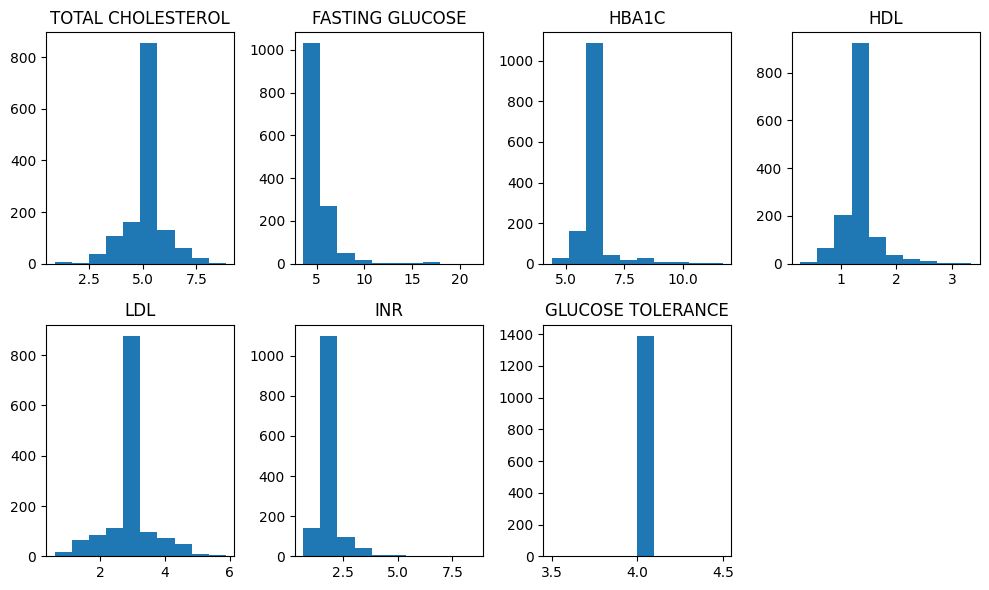


Histogram with 30 bins


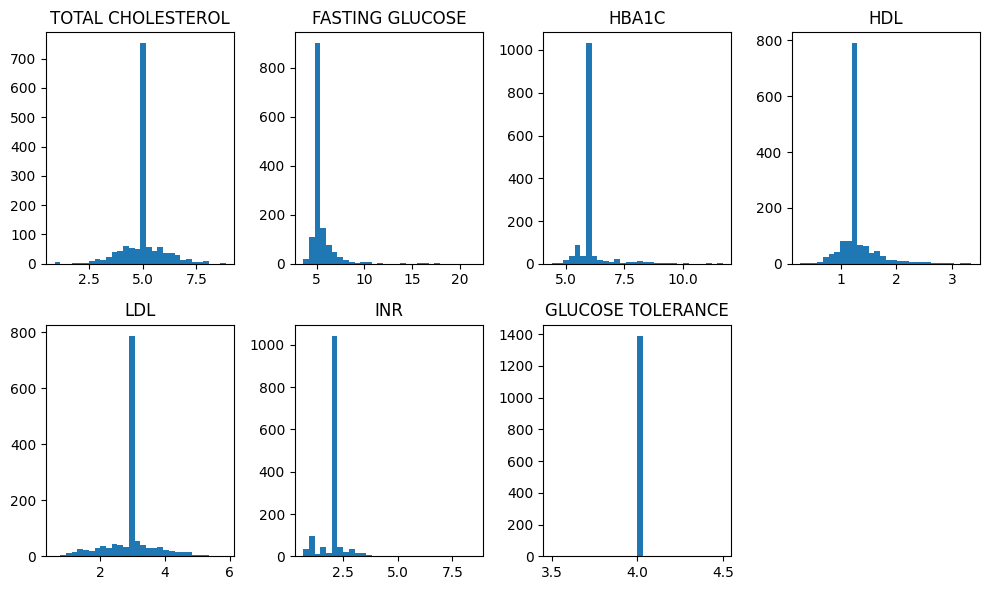

In [11]:
# Plot histograms for lab markers to check distributions
#Histogram with default 10 bins
print("Histogram with 10 bins")
plt.figure(figsize=(10, 6))  
for i, col in enumerate(lab_cols_all, 1): 
    plt.subplot(2, 4, i)
    plt.hist(df_all_vars[col], bins=10)  
    plt.title(col.replace('_', ' ')) 
plt.tight_layout()
plt.show()

#Histogram with 30 bins to emphasize the concentration around mean
print("\nHistogram with 30 bins")
plt.figure(figsize=(10, 6))  
for i, col in enumerate(lab_cols_all, 1):
    plt.subplot(2, 4, i)
    plt.hist(df_all_vars[col], bins=30)  
    plt.title(col.replace('_', ' '))  
plt.tight_layout()
plt.show()


                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.044784 -0.043981  0.125251   
FASTING GLUCOSE            -0.044784         1.000000  0.407156 -0.067002   
HBA1C                      -0.043981         0.407156  1.000000 -0.079553   
HDL                         0.125251        -0.067002 -0.079553  1.000000   
LDL                         0.784656        -0.095279 -0.087852 -0.036328   
INR                         0.009374        -0.010074  0.004513 -0.006467   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.784656  0.009374                NaN  
FASTING GLUCOSE   -0.095279 -0.010074                NaN  
HBA1C             -0.087852  0.004513                NaN  
HDL               -0.036328 -0.006467                NaN  
LDL                1.000000  0.018753                NaN  
INR                0.018753  

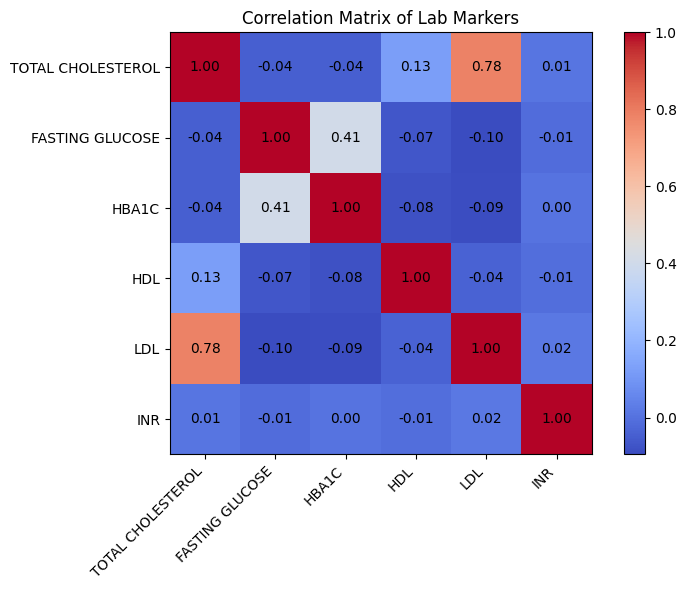

In [21]:
#Check correlation matrix 
corr_matrix = df_all_vars[lab_cols_all].corr()
print(corr_matrix)

#To avoid NaN results, exclude GLUCOSE TOLERANCE 
lab_cols = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
corr_matrix_reduced = df_all_vars[lab_cols].corr()

#Heatmap 
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix_reduced, cmap='coolwarm')
plt.colorbar()

# Set ticks and labels
plt.xticks(range(len(lab_cols)), lab_cols, rotation=45, ha='right')
plt.yticks(range(len(lab_cols)), lab_cols)

# Add correlation values
for i in range(len(lab_cols)):
    for j in range(len(lab_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center')

# Add title and show
plt.title('Correlation Matrix of Lab Markers')
plt.tight_layout()
plt.show()